# Exploring Shot Events in La Liga 2017/18: A Statistical Analysis of Shooting Patterns and Outcomes

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

## Data loading and preprocessing

In [2]:
# ── Load ──────────────────────────────────────────────────────────────────────
with open("final_df.json", "r") as f:
    data = json.load(f)

df_raw = pd.DataFrame(data)

# ── Select & rename ───────────────────────────────────────────────────────────
cols = {
    "shot.statsbomb_xg":   "xg",
    "shot.outcome.name":   "outcome",
    "shot.body_part.name": "body_part",
    "play_pattern.name":   "play_pattern",
    "under_pressure":      "under_pressure",
    "shot.first_time":     "first_time",
    "location":            "location",
}

df = df_raw[list(cols.keys())].rename(columns=cols).copy()

print("Shape after selection:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nSample:\n", df.head(3))

Shape after selection: (971, 7)

Columns: ['xg', 'outcome', 'body_part', 'play_pattern', 'under_pressure', 'first_time', 'location']

Sample:
          xg  outcome   body_part    play_pattern under_pressure first_time  \
0  0.008752    Saved  Right Foot   From Throw In           None       None   
1  0.053915  Blocked  Right Foot  From Free Kick           None       None   
2  0.080842    Saved   Left Foot   From Throw In           None       True   

        location  
0  [101.0, 21.3]  
1  [103.9, 28.4]  
2  [112.5, 26.0]  


In [3]:
# Drop the "Other" body part category due to its ambiguity and low frequency
df = df[df["body_part"] != "Other"].reset_index(drop=True)

# Derive the goal indicator column from the outcome column
df["goal"] = (df["outcome"] == "Goal").astype(int)

# Derive the distance from the goal
# The location coordinates are in the format (x, y), where (0, 0) is the bottom left corner of the pitch and (120, 80) is the top right corner.
GOAL_X, GOAL_Y = 120.0, 40.0
df["loc_x"] = df["location"].apply(lambda v: v[0])
df["loc_y"] = df["location"].apply(lambda v: v[1])
df["distance"] = np.sqrt((df["loc_x"] - GOAL_X)**2 + (df["loc_y"] - GOAL_Y)**2)

# Derive the angle between the shot and the goal
POST1_Y, POST2_Y = 36.0, 44.0

def shot_angle(x, y):
    """
    Calculate the angle between the shot and the goal.
    :param x: shot x coordinate
    :param y: shot y coordinate
    :return: calculate angle in degrees
    """
    dx  = GOAL_X - x
    dy1 = POST1_Y - y
    dy2 = POST2_Y - y
    a1  = np.arctan2(dy1, dx)
    a2  = np.arctan2(dy2, dx)
    angle = np.abs(a2 - a1)
    angle = np.where(angle > np.pi, 2*np.pi - angle, angle)
    return np.degrees(angle)

# Calculate the angle between the shot and the goal
df["angle"] = shot_angle(df["loc_x"].values, df["loc_y"].values)

# Fill binary NaN values with False
for col in ["under_pressure", "first_time"]:
    df[col] = df[col].fillna(False).astype(bool)

# Group the small categories of play patterns into the "Other" category (less than 10 chances)
minor = ["From Kick Off", "Other", "From Keeper"]
df["play_pattern"] = df["play_pattern"].apply(lambda x: "Other" if x in minor else x)

# Final selection
df = df[["xg", "distance", "angle", "goal","body_part", "play_pattern","under_pressure", "first_time"]].copy()

In [4]:
# Validation
print("Final shape:", df.shape)
print("\nSample:\n", df.head(3))

Final shape: (968, 8)

Sample:
          xg   distance      angle  goal   body_part    play_pattern  \
0  0.008752  26.658770  12.341965     0  Right Foot   From Throw In   
1  0.053915  19.843639  18.826717     0  Right Foot  From Free Kick   
2  0.080842  15.882380  14.250033     0   Left Foot   From Throw In   

   under_pressure  first_time  
0           False       False  
1           False       False  
2           False        True  


## Descriptive analytics

### Summary statistics for quantitative variables

In [5]:
summary = df[["xg", "distance", "angle"]].describe().T
summary.columns = ["Count", "Mean", "Std", "Min", "Q1", "Median", "Q3", "Max"]
summary = summary[["Mean", "Std", "Min", "Q1", "Median", "Q3", "Max"]]
summary = summary.round(4)
print("=== SUMMARY STATISTICS ===")
print(summary)

=== SUMMARY STATISTICS ===
             Mean      Std     Min       Q1   Median       Q3       Max
xg         0.1122   0.1483  0.0032   0.0339   0.0620   0.1162    0.8915
distance  18.5415   8.1612  2.2804  12.1649  17.6739  24.2466   65.8825
angle     25.2749  14.4881  1.8361  15.5944  20.3796  30.6973  121.5348


### Goal Rate overall and by group

#### Overall goal rate

In [6]:
print(f"Goals: {df['goal'].sum()} / {len(df)} = {df['goal'].mean():.4f}")

Goals: 112 / 968 = 0.1157


#### Goal rate by body part

In [7]:
print(df.groupby("body_part")["goal"].agg(["sum", "count", "mean"]).round(4))

            sum  count    mean
body_part                     
Head          9    122  0.0738
Left Foot    51    407  0.1253
Right Foot   52    439  0.1185


#### Goal rate by play pattern

In [8]:
print(df.groupby("play_pattern")["goal"].agg(["sum", "count", "mean"]).round(4))

                sum  count    mean
play_pattern                      
From Corner      11    156  0.0705
From Counter      6     53  0.1132
From Free Kick   15    190  0.0789
From Goal Kick    4     32  0.1250
From Throw In    18    136  0.1324
Other             8     25  0.3200
Regular Play     50    376  0.1330


#### Goal rate by pressure

In [9]:
print(df.groupby("under_pressure")["goal"].agg(["sum", "count", "mean"]).round(4))

                sum  count    mean
under_pressure                    
False            93    820  0.1134
True             19    148  0.1284


#### Goal rate by first time shot

In [10]:
print(df.groupby("first_time")["goal"].agg(["sum", "count", "mean"]).round(4))

            sum  count    mean
first_time                    
False        56    645  0.0868
True         56    323  0.1734


## Visualizations

### Distribution of xG, distance, angle

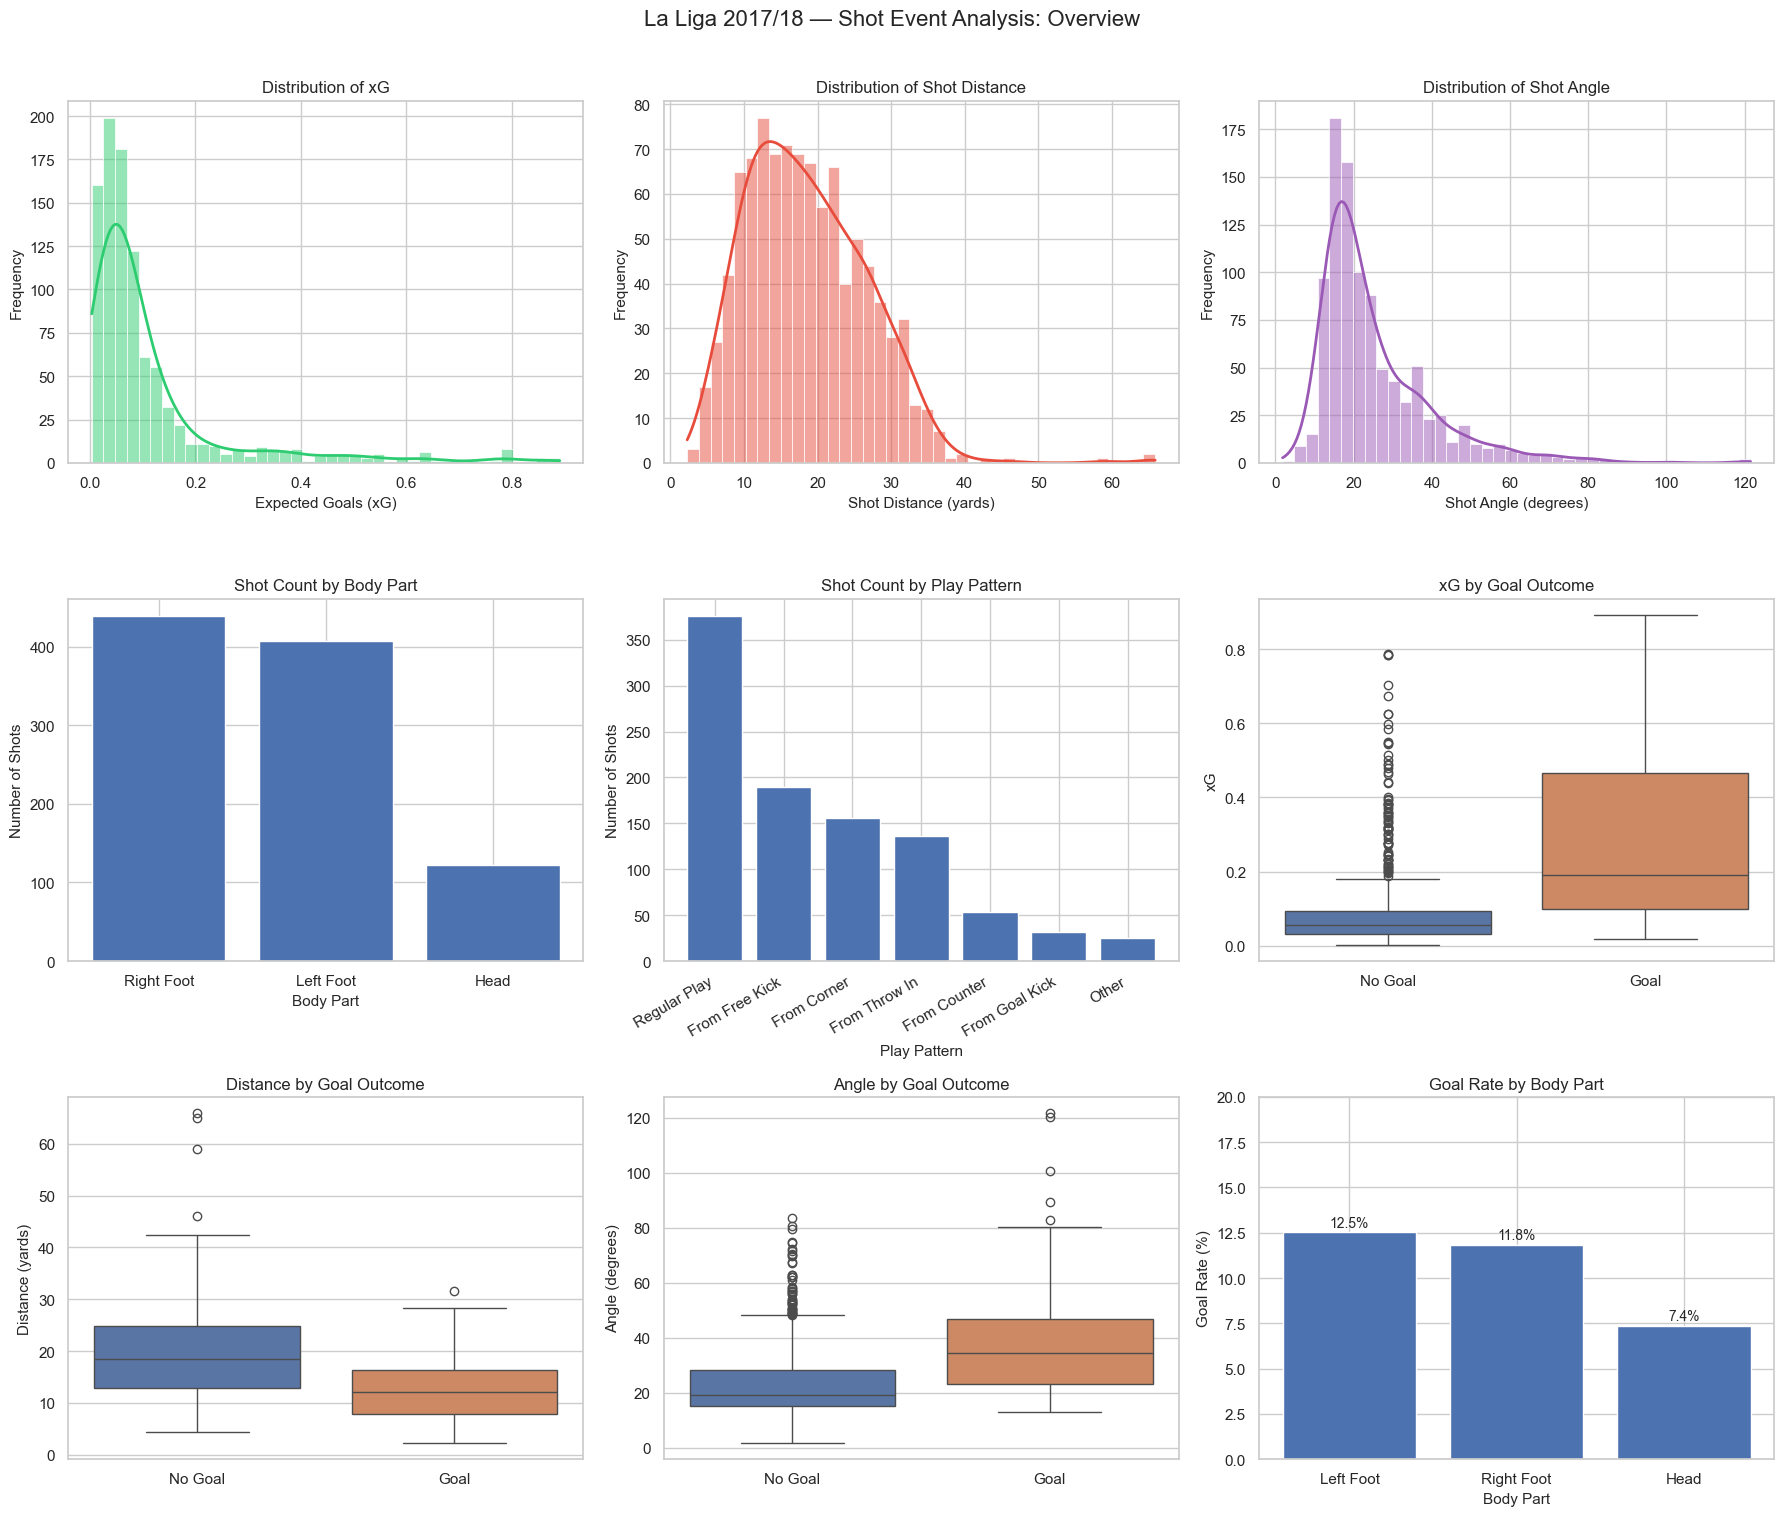

Figure saved to figures/fig_overview_grid.png


In [12]:
import os
os.makedirs("figures", exist_ok=True)
sns.set_theme(style="whitegrid", palette="muted")

fig, axes = plt.subplots(3, 3, figsize=(18, 15))

# Distribution of xG
sns.histplot(df["xg"], bins=40, ax=axes[0,0], color="#2ecc71",edgecolor="white", linewidth=0.5, kde=True, line_kws={"color": "#1a8a4a", "linewidth": 2})
axes[0,0].set_xlabel("Expected Goals (xG)", fontsize=11)
axes[0,0].set_ylabel("Frequency", fontsize=11)
axes[0,0].set_title("Distribution of xG", fontsize=12)

# Distribution of shot distance
sns.histplot(df["distance"], bins=40, ax=axes[0,1], color="#e74c3c",edgecolor="white", linewidth=0.5, kde=True,line_kws={"color": "#a93226", "linewidth": 2})
axes[0,1].set_xlabel("Shot Distance (yards)", fontsize=11)
axes[0,1].set_ylabel("Frequency", fontsize=11)
axes[0,1].set_title("Distribution of Shot Distance", fontsize=12)

# Distribution of shot angle
sns.histplot(df["angle"], bins=40, ax=axes[0,2], color="#9b59b6",edgecolor="white", linewidth=0.5, kde=True, line_kws={"color": "#6c3483", "linewidth": 2})
axes[0,2].set_xlabel("Shot Angle (degrees)", fontsize=11)
axes[0,2].set_ylabel("Frequency", fontsize=11)
axes[0,2].set_title("Distribution of Shot Angle", fontsize=12)

# Shot count by body part
body_counts = df["body_part"].value_counts()
axes[1,0].bar(body_counts.index, body_counts.values, color="#4C72B0", edgecolor="white")
axes[1,0].set_xlabel("Body Part", fontsize=11)
axes[1,0].set_ylabel("Number of Shots", fontsize=11)
axes[1,0].set_title("Shot Count by Body Part", fontsize=12)

# Shot count by play pattern
pattern_counts = df["play_pattern"].value_counts()
axes[1,1].bar(pattern_counts.index, pattern_counts.values, color="#4C72B0", edgecolor="white")
axes[1,1].set_xlabel("Play Pattern", fontsize=11)
axes[1,1].set_ylabel("Number of Shots", fontsize=11)
axes[1,1].set_title("Shot Count by Play Pattern", fontsize=12)
axes[1,1].tick_params(axis="x", rotation=30)
for label in axes[1,1].get_xticklabels():
    label.set_ha("right")

# Box plots of xG, distance, angle by goal outcome
df["goal_label"] = df["goal"].map({0: "No Goal", 1: "Goal"})
sns.boxplot(data=df, x="goal_label", y="xg", ax=axes[1,2], hue="goal_label", palette={"No Goal": "#4C72B0", "Goal": "#DD8452"}, order=["No Goal", "Goal"], legend=False)
axes[1,2].set_xlabel("")
axes[1,2].set_ylabel("xG", fontsize=11)
axes[1,2].set_title("xG by Goal Outcome", fontsize=12)

# Box plot of distance by goal outcome
sns.boxplot(data=df, x="goal_label", y="distance", ax=axes[2,0], hue="goal_label", palette={"No Goal": "#4C72B0", "Goal": "#DD8452"}, order=["No Goal", "Goal"], legend=False)
axes[2,0].set_xlabel("")
axes[2,0].set_ylabel("Distance (yards)", fontsize=11)
axes[2,0].set_title("Distance by Goal Outcome", fontsize=12)

# Box plot of angle by goal outcome
sns.boxplot(data=df, x="goal_label", y="angle", ax=axes[2,1], hue="goal_label", palette={"No Goal": "#4C72B0", "Goal": "#DD8452"},order=["No Goal", "Goal"], legend=False)
axes[2,1].set_xlabel("")
axes[2,1].set_ylabel("Angle (degrees)", fontsize=11)
axes[2,1].set_title("Angle by Goal Outcome", fontsize=12)

# Goal rate by body part
goal_rate_bp = df.groupby("body_part")["goal"].mean().sort_values(ascending=False)
axes[2,2].bar(goal_rate_bp.index, goal_rate_bp.values * 100, color="#4C72B0", edgecolor="white")
axes[2,2].set_xlabel("Body Part", fontsize=11)
axes[2,2].set_ylabel("Goal Rate (%)", fontsize=11)
axes[2,2].set_title("Goal Rate by Body Part", fontsize=12)
axes[2,2].set_ylim(0, 20)
for i, v in enumerate(goal_rate_bp.values):
    axes[2,2].text(i, v * 100 + 0.3, f"{v*100:.1f}%", ha="center", fontsize=10)

# Finalize layout and save figure
df.drop(columns=["goal_label"], inplace=True)
plt.suptitle("La Liga 2017/18 — Shot Event Analysis: Overview", fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig("figures/fig_overview_grid.png", dpi=150, bbox_inches="tight")
plt.show()

print("Figure saved to figures/fig_overview_grid.png")

### Shot map

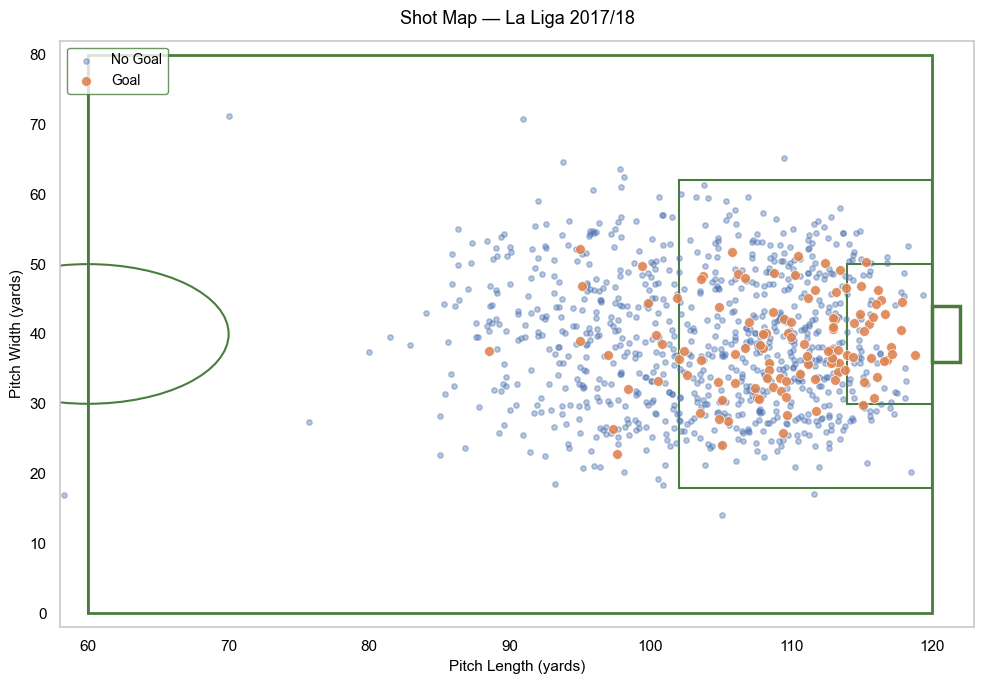

Shot map saved to figures/fig_shot_map.png


In [17]:
# ── Shot map on the attacking half of the pitch ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor("white")

# Draw the pitch background
ax.set_facecolor("white")
# Pitch outline (attacking half only: x from 60 to 120)
ax.add_patch(plt.Rectangle((60, 0), 60, 80,fill=False, edgecolor="#4a7c3f", linewidth=2))
# Halfway line
ax.plot([60, 60], [0, 80], color="#4a7c3f", linewidth=1.5)
# Penalty area
ax.add_patch(plt.Rectangle((102, 18), 18, 44,fill=False, edgecolor="#4a7c3f", linewidth=1.5))
# Six-yard box
ax.add_patch(plt.Rectangle((114, 30), 6, 20,fill=False, edgecolor="#4a7c3f", linewidth=1.5))
# Goal
ax.add_patch(plt.Rectangle((120, 36), 2, 8,fill=False, edgecolor="#4a7c3f", linewidth=2.5))
# Penalty spot
ax.plot(108, 40, "o", color="#4a7c3f", markersize=3)
# Centre circle arc (partial)
centre_circle = plt.Circle((60, 40), 10, fill=False,edgecolor="#4a7c3f", linewidth=1.5)
ax.add_patch(centre_circle)

# Re drive locations
with open("final_df.json", "r") as f:
    data = json.load(f)
df_raw = pd.DataFrame(data)
df_raw = df_raw[df_raw["shot.body_part.name"] != "Other"].reset_index(drop=True)
df["loc_x"] = df_raw["location"].apply(lambda v: v[0])
df["loc_y"] = df_raw["location"].apply(lambda v: v[1])

# Plot shots
no_goals = df[df["goal"] == 0]
goals    = df[df["goal"] == 1]

ax.scatter(no_goals["loc_x"], no_goals["loc_y"],c="#4C72B0", s=15, alpha=0.4, label="No Goal", zorder=3)
ax.scatter(goals["loc_x"], goals["loc_y"],c="#DD8452", s=50, alpha=0.9, label="Goal",edgecolors="white", linewidth=0.5, zorder=4)

# Labels and formatting
ax.set_xlim(58, 123)
ax.set_ylim(-2, 82)
ax.set_xlabel("Pitch Length (yards)", fontsize=11, color="black")
ax.set_ylabel("Pitch Width (yards)", fontsize=11, color="black")
ax.set_title("Shot Map — La Liga 2017/18", fontsize=13, color="black", pad=12)
ax.tick_params(colors="black")
ax.grid(False)
ax.legend(loc="upper left", fontsize=10, facecolor="white", labelcolor="black", framealpha=0.8, edgecolor="#4a7c3f")
fig.patch.set_facecolor("white")

plt.tight_layout()
plt.savefig("figures/fig_shot_map.png", dpi=150, bbox_inches="tight")
plt.show()

print("Shot map saved to figures/fig_shot_map.png")

## Univariate analysis

## Correlation analysis

### Pearson Matrix

=== PEARSON CORRELATION MATRIX ===
              xg  distance   angle
xg        1.0000   -0.5337  0.6639
distance -0.5337    1.0000 -0.7370
angle     0.6639   -0.7370  1.0000


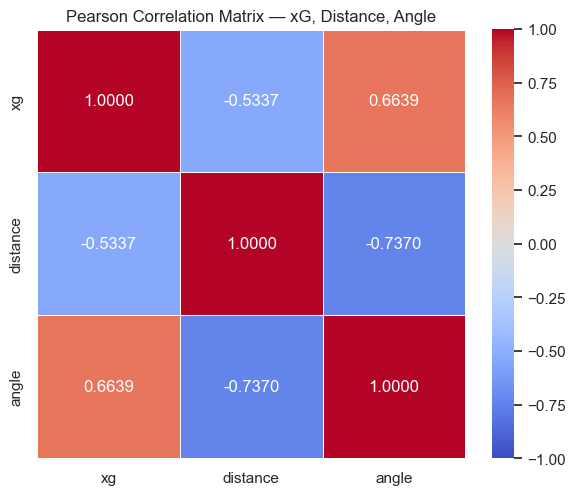

Heatmap saved to figures/fig_correlation_heatmap.png


In [18]:
# ── Pearson correlation matrix ────────────────────────────────────────────────
corr_matrix = df[["xg", "distance", "angle"]].corr(method="pearson")
print("=== PEARSON CORRELATION MATRIX ===")
print(corr_matrix.round(4))

# ── Heatmap ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".4f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5,
            annot_kws={"size": 12}, ax=ax)
ax.set_title("Pearson Correlation Matrix — xG, Distance, Angle", fontsize=12)
plt.tight_layout()
plt.savefig("figures/fig_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print("Heatmap saved to figures/fig_correlation_heatmap.png")

### Heatmap of xG by distance and angle